$$
\begin{gather*}
\text{Se importan las librerías necesarias y se definen las rutas de acceso, tanto para la imagen de origen} \\
\text{---de la cual se extraerán el contorno y el área--- como para el archivo de salida que} \\
\text{almacenará las coordenadas de los puntos generados.}
\end{gather*}
$$

In [15]:
import os

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

img_path = r"../assets/bubbleGuppie.jpeg"
output_xlsx = r"../assets/bubble_guppies_coordinate_mapping.xlsx"

y_up =   True  # True y grows upward; False -> image coordinates (y down)


In [16]:
def pick_contour(contours, shape):
    height, width = shape

    def touches_border(cnt):
        x, y, w, h = cv2.boundingRect(cnt)
        return x <= 1 or y <= 1 or x + w >= width - 1 or y + h >= height - 1

    inner = [c for c in contours if not touches_border(c)]
    candidates = inner if inner else contours
    if not candidates:
        return None
    return max(candidates, key=cv2.contourArea)


def build_mask(image):
    blur = cv2.GaussianBlur(image, (5, 5), 0)

    border = np.vstack(
        [
            blur[:10, :, :].reshape(-1, 3),
            blur[-10:, :, :].reshape(-1, 3),
            blur[:, :10, :].reshape(-1, 3),
            blur[:, -10:, :].reshape(-1, 3),
        ]
    )
    bg_color = np.median(border, axis=0)

    diff = np.linalg.norm(blur.astype(np.float32) - bg_color, axis=2)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    return cleaned


def smooth_contour(points, window):
    if window <= 1:
        return points
    if window % 2 == 0:
        window += 1

    kernel = np.ones(window, dtype=float) / window
    pad = window // 2
    padded = np.vstack([points[-pad:], points, points[:pad]])
    x = np.convolve(padded[:, 0], kernel, mode="valid")
    y = np.convolve(padded[:, 1], kernel, mode="valid")
    return np.column_stack([x, y])


image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"No se encontro la imagen: {img_path}")

mask = build_mask(image)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contour = pick_contour(contours, mask.shape)
if contour is None:
    raise ValueError("No se encontro un contorno valido.")

contour_xy = contour[:, 0, :].astype(float)
contour_xy = smooth_contour(contour_xy, window=2)

contour_xy_for_plot = contour_xy.copy()

if y_up:
    height = image.shape[0]
    contour_xy = contour_xy.copy()
    contour_xy[:, 1] = (height - 1) - contour_xy[:, 1]

points = pd.DataFrame({"x": contour_xy[:, 0], "y": contour_xy[:, 1]})
points.to_excel(output_xlsx, index=False)

points.head()


,x,y
0,97.333333,322.666667
1,97.000000,322.000000
2,97.000000,321.000000
3,97.000000,320.000000
4,97.000000,319.000000


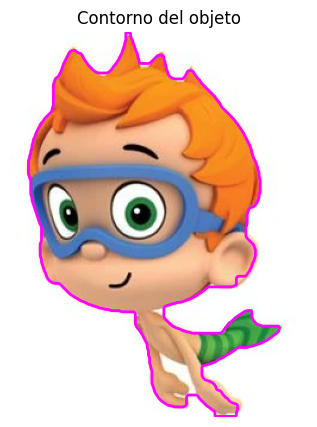

Excel guardado en: ../assets/bubble_guppies_coordinate_mapping.xlsx


In [17]:
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

contour_closed = np.vstack([contour_xy_for_plot, contour_xy_for_plot[0]])
plt.plot(contour_closed[:, 0], contour_closed[:, 1], color="magenta", linewidth=2)

plt.title("Contorno del objeto")
plt.axis("off")
plt.show()

print(f"Excel guardado en: {output_xlsx}")


$$
\begin{gather*}
\text{Para el cálculo del área del polígono definido por el contorno, se implementa la fórmula de Gauss:} \\
A = \frac{1}{2} \left| \sum_{i=1}^{n} x_i y_{i+1} - \sum_{i=1}^{n} y_i x_{i+1} \right| \\
\text{En la función \texttt{polygon\_area}, esto se optimiza mediante operaciones vectoriales con NumPy:} \\
\text{1. Se extraen los vectores de coordenadas } x \text{ e } y \text{ de los puntos del contorno.} \\
\text{2. Se utiliza \texttt{np.roll} para desplazar los índices y obtener los términos } y_{i+1} \text{ y } x_{i+1} \text{ (cerrando el ciclo).} \\
\text{3. Se calcula el producto punto (\texttt{np.dot}) para realizar las sumatorias y se obtiene la magnitud final.}
\end{gather*}
$$

In [18]:
def polygon_area(points):
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

area = polygon_area(contour_xy)
print(f"Area del contorno (pixeles^2): {area:.2f}")

Area del contorno (pixeles^2): 38332.78


$$
\begin{gather*}
\text{Como validación y método alternativo, se utiliza la función nativa de OpenCV \texttt{cv2.contourArea(contour)}.} \\
\text{Esta función implementa una versión optimizada del algoritmo de Green para el cálculo de áreas} \\
\text{en superficies planas, el cual se basa en la integral de línea alrededor del contorno:} \\
A = \oint_{C} x \, dy \\
\end{gather*}
$$

In [19]:
area_cv2 = cv2.contourArea(contour)
print(f"Area con cv2.contourArea(): {area_cv2:.2f}")

Area con cv2.contourArea(): 38331.50


$$
\begin{gather*}
\text{Se genera una representación gráfica exclusiva del contorno mediante la librería \textbf{matplotlib}.} \\
\text{Para asegurar que la silueta sea una curva cerrada, se emplea \texttt{np.vstack}, concatenando el} \\
\text{primer punto al final del arreglo de coordenadas (\textit{cierre del polígono}).} \\
\text{La visualización se configura con una relación de aspecto unitaria (\texttt{set\_aspect('equal')}) para} \\
\text{evitar distorsiones en la geometría original y se exporta como una imagen de alta resolución} \\
\text{(\texttt{.png}) en el directorio de recursos del proyecto.}
\end{gather*}
$$

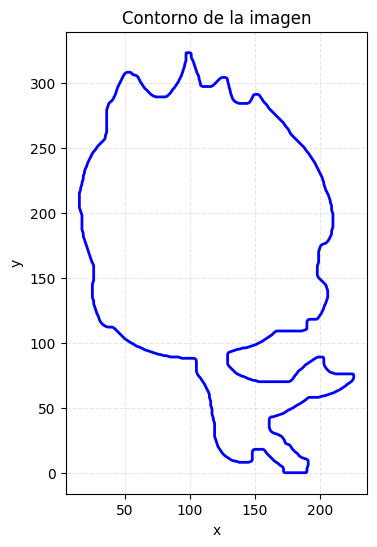

In [20]:
# 1) Contorno exclusivo
plt.figure(figsize=(6, 6))
contour_closed = np.vstack([contour_xy, contour_xy[0]])
plt.plot(contour_closed[:, 0], contour_closed[:, 1], color="blue", linewidth=2)
plt.title("Contorno de la imagen")
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("../assets/bubble_guppie_contour_exclusive.png", dpi=150, bbox_inches="tight")
plt.show()

plt.close()